<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# TP1 - White Patch y Análisis de Histogramas

**Materia:** Visión por Computadora I

**Profesor:** Ing. Maxim Dorogov

**Alumnos:** <br>
Juan Sebastián Bonals - jsbonals@gmail.com  <br>
Federico Santiago Fontanari - federicofontanari@gmail.com  <br>
Jose Andres Montes de Oca - amontesdeoca1982@gmail.com  <br>

Este notebook resuelve las dos partes del TP1:

1. **Parte 1:** implementación del algoritmo *White Patch* sobre las imágenes de `white_patch/` para corregir dominancias de color en la iluminación, y análisis de sus posibles fallas.
2. **Parte 2:** lectura de `img1_tp.png` e `img2_tp.png` en escala de grises, cálculo y comparación de histogramas, y discusión sobre su utilidad como *features* para clasificación/detección.

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob
import os

%matplotlib inline

In [ ]:
REPO_URL = 'https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_I.git'
REPO_DIR = 'vision_computadora_I'

if not os.path.exists(REPO_DIR):
    !git clone -q {REPO_URL}

if not os.path.exists('white_patch'):
    os.symlink(f'{REPO_DIR}/Material_TPs/TP1/white_patch', 'white_patch')
    os.symlink(f'{REPO_DIR}/Material_TPs/TP1/img1_tp.png', 'img1_tp.png')
    os.symlink(f'{REPO_DIR}/Material_TPs/TP1/img2_tp.png', 'img2_tp.png')

BASE_DIR = '.'

## Parte 1: White Patch

### El algoritmo

El algoritmo de White Patch parte de la hipótesis de que en toda escena existe al menos un punto que debería verse blanco. Bajo una fuente de luz con dominancia de color, ese punto blanco se ve teñido, por lo tanto, si encontramos el valor máximo de cada canal de color y lo llevamos a 255, estamos "recalibrando" la iluminación de la escena:

Para cada canal de color:

$$R'(x,y) = R(x,y) \cdot \frac{255}{\max(R)} $$


$$G'(x,y) = G(x,y) \cdot \frac{255}{\max(G)} $$


$$B'(x,y) = B(x,y) \cdot \frac{255}{\max(B)} $$

Una variante más robusta usa un percentil alto (ej. 99) en lugar del máximo estricto, para no depender de un único píxel ruidoso.

In [ ]:
def white_patch(img_bgr, percentil=100):
    # Aplica el algoritmo de White Patch canal a canal.
    # percentil=100 -> usa el maximo estricto de cada canal (White Patch clasico)
    # percentil<100 -> usa ese percentil como referencia de "blanco" (mas robusto a outliers)
    img_f = img_bgr.astype(np.float32)
    salida = np.zeros_like(img_f)
    for c in range(3):
        canal = img_f[:, :, c]
        if percentil >= 100:
            ref = canal.max()
        else:
            ref = np.percentile(canal, percentil)
        ref = max(ref, 1e-6)  # evitar division por cero
        salida[:, :, c] = canal * (255.0 / ref)
    return np.clip(salida, 0, 255).astype(np.uint8)

In [ ]:
#Revisamos las imagenes que estan en la carpeta "white_patch"
paths = sorted(glob.glob(os.path.join(BASE_DIR, 'white_patch', '*')))
print(f'Se encontraron {len(paths)} imagenes en white_patch/:')
for p in paths:
    print(' -', os.path.basename(p))

Se encontraron 8 imagenes en white_patch/:
 - test_blue.png
 - test_green.png
 - test_red.png
 - wp_blue.jpg
 - wp_green.png
 - wp_green2.jpg
 - wp_red.png
 - wp_red2.jpg


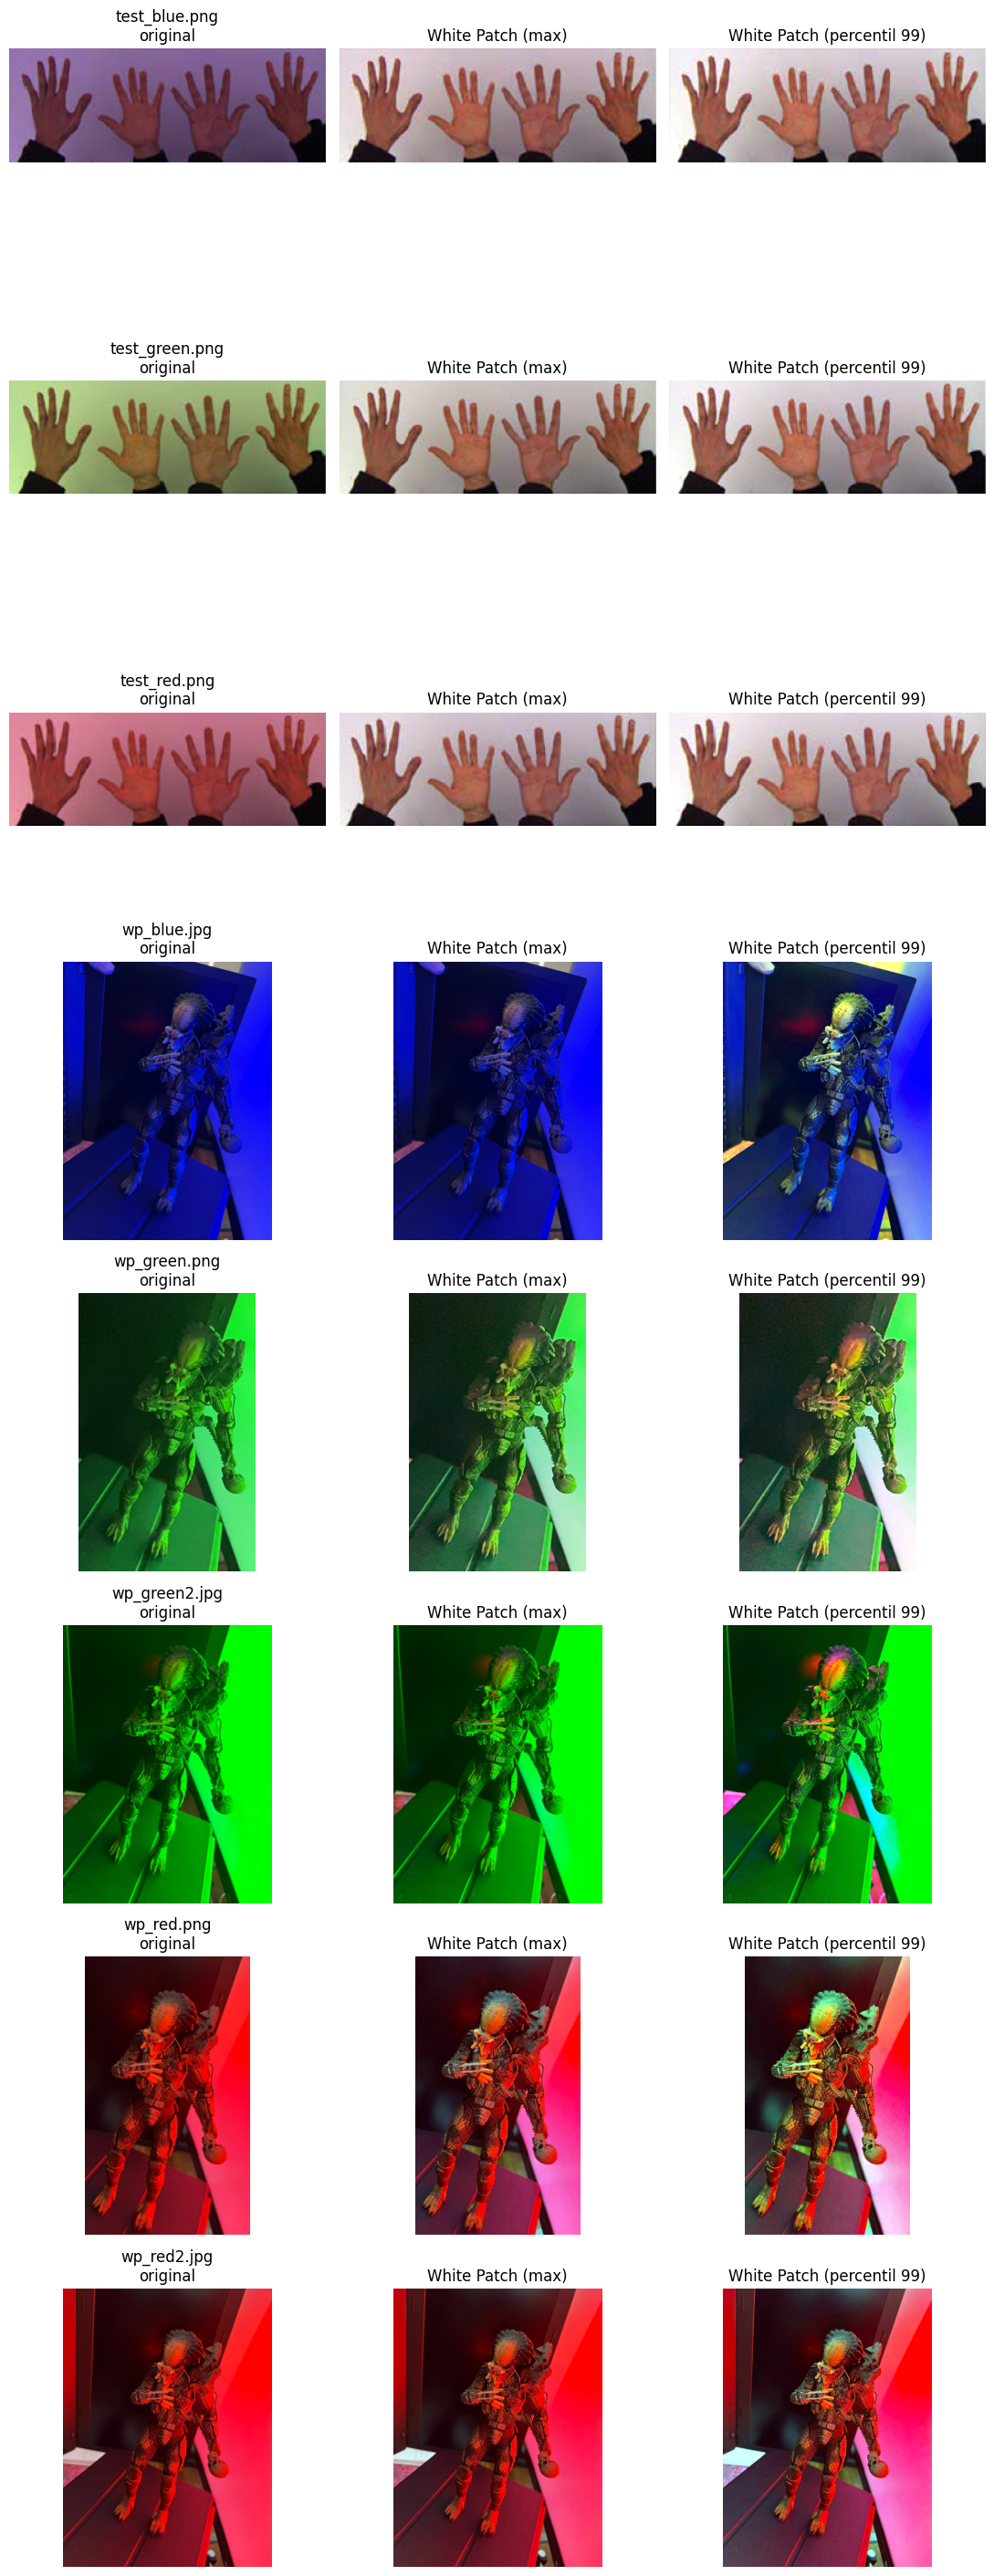

In [ ]:
#Graficamos:
fig, axes = plt.subplots(len(paths), 3, figsize=(11, 3.6*len(paths)))

for i, p in enumerate(paths):
    img = cv.imread(p)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    corr_max = cv.cvtColor(white_patch(img, percentil=100), cv.COLOR_BGR2RGB)
    corr_p99 = cv.cvtColor(white_patch(img, percentil=99), cv.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_rgb); axes[i, 0].set_title(f'{os.path.basename(p)}\noriginal'); axes[i, 0].axis('off')
    axes[i, 1].imshow(corr_max); axes[i, 1].set_title('White Patch (max)'); axes[i, 1].axis('off')
    axes[i, 2].imshow(corr_p99); axes[i, 2].set_title('White Patch (percentil 99)'); axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

### Análisis de resultados y posibles fallas

Al observar los resultados se distinguen dos comportamientos muy distintos:

- **`test_blue.png`, `test_green.png`, `test_red.png` (fotos de manos):** el algoritmo corrige muy bien la dominancia de color. En estas escenas hay una pared de fondo blanca que actúa como una referencia de blanco. La hipotesis del White Patch se cumple y el resultado se ve con tonos de piel naturales.

- **`wp_blue.jpg`, `wp_green.png`, `wp_green2.jpg`, `wp_red.png`, `wp_red2.jpg` (Depredador bajo distintas luces de colores):** el algoritmo falla parcial o totalmente ya que la dominancia de color prácticamente no se corrige. Esto pasa porque:

  1. **No hay un verdadero blanco en la escena.** Toda la imagen está teñida por la luz de color. El valor máximo de cada canal no corresponde a una superficie que debería ser blanca, sino simplemente al punto más iluminado.
  2. **Saturación del canal.** En las imágenes gran parte de la escena está sobreexpuesta en el canal dominante. Escalar por el máximo no hace nada en esos píxeles ya que se dividen por sí mismo. Además fuerza al resto de los píxeles de ese canal a compararse contra una referencia que ya estaba saturada.

- La variante con **percentil 99** en general da resultados más equilibrados que el máximo estricto, porque no depende de un único píxel extremo. De todas formas, tampoco alcanza para corregir la dominacia de color, porque el problema no es un outlier puntual sino la ausencia de una referencia blanca.

White Patch es simple y efectivo cuando la escena contiene un punto verdaderamente acromático. Cuando la iluminación es muy saturada o monocromática y no hay ninguna referencia de blanco, el algoritmo no tiene información suficiente para separar "color del objeto" de "color de la luz", y el resultado sigue mostrando el color dominante.

## Parte 2: Lectura y comparación de histogramas

Leemos `img1_tp.png` e `img2_tp.png` con OpenCV en escala de grises y las visualizamos.

img1_tp.png -> (288, 287) uint8
img2_tp.png -> (288, 287) uint8


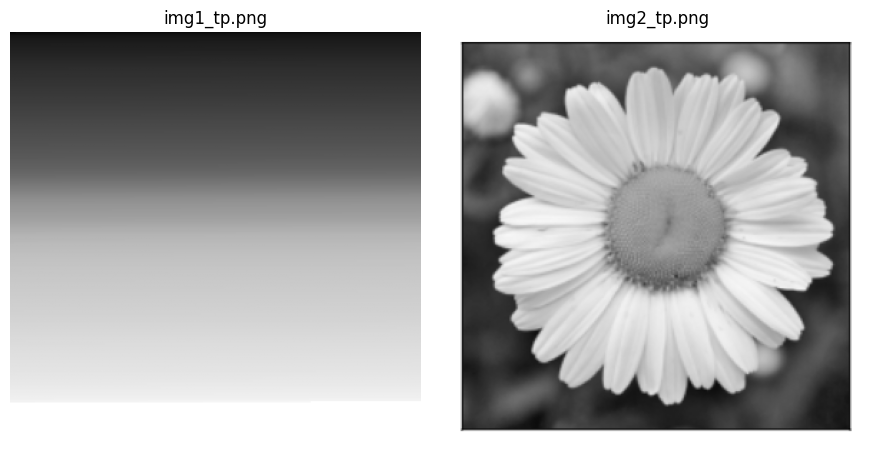

In [ ]:
img1 = cv.imread(os.path.join(BASE_DIR, 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(os.path.join(BASE_DIR, 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

print('img1_tp.png ->', img1.shape, img1.dtype)
print('img2_tp.png ->', img2.shape, img2.dtype)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img1, cmap='gray', vmin=0, vmax=255); axes[0].set_title('img1_tp.png'); axes[0].axis('off')
axes[1].imshow(img2, cmap='gray', vmin=0, vmax=255); axes[1].set_title('img2_tp.png'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### Elección del número de bins

Elegimos 32 bins porque:

- Con 256 bins el histograma queda muy ruidoso. Se mostrarian muchas barras con conteos bajos y saltos bruscos entre niveles adyacentes. Esto dificulta ver la forma global de la distribución.
- Con 32 bins agrupamos en 8 rangos consecutivos, obteniendo una forma mucho más suave y fácil de comparar visualmente, sin perder la estructura de la distribucion (modas, dispersión)
- Como regla general, bins muy grandes (ej. 8) esconderían demasiados detalles y bins muy chicos (ej. 256) mostraria muchas barras.

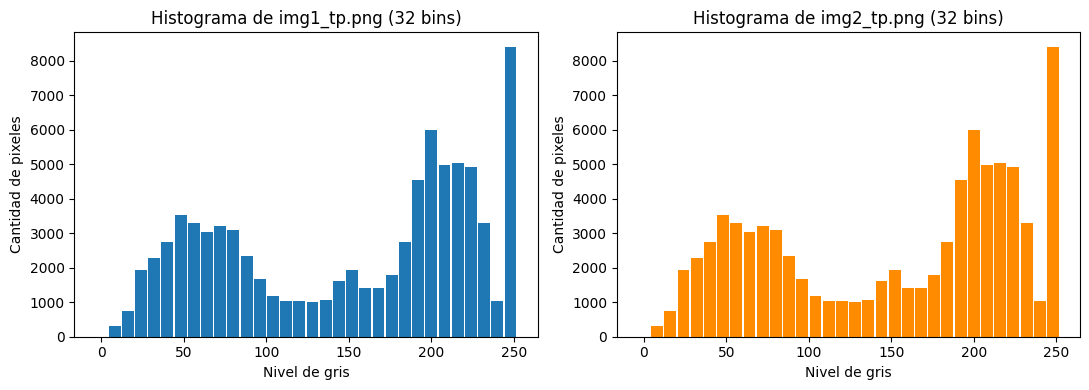

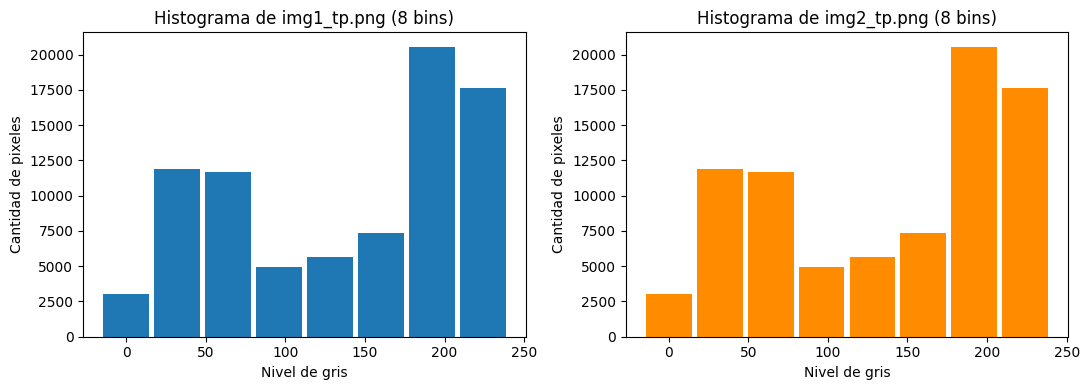

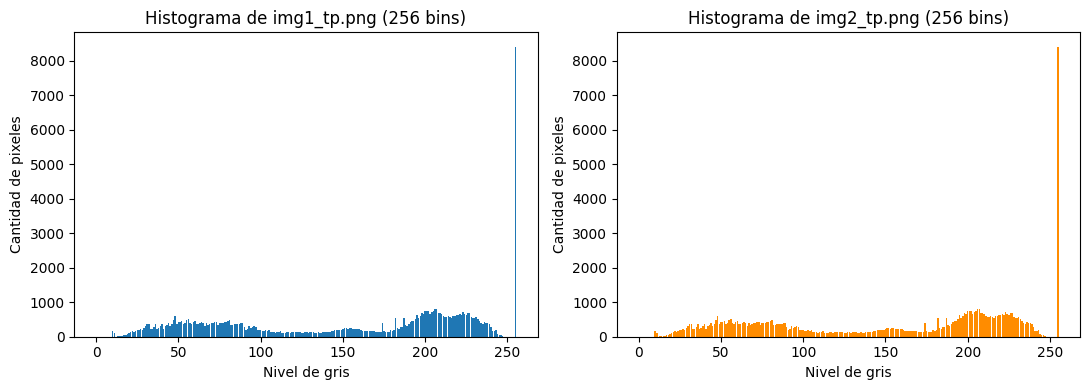

In [ ]:
for n_bins in [32, 8, 256]:
#n_bins = 32

  hist1, bins1 = np.histogram(img1.ravel(), bins=n_bins, range=(0, 256))
  hist2, bins2 = np.histogram(img2.ravel(), bins=n_bins, range=(0, 256))

  fig, axes = plt.subplots(1, 2, figsize=(11, 4))
  ancho = (256 / n_bins) * 0.9
  axes[0].bar(bins1[:-1], hist1, width=ancho)
  axes[0].set_title(f'Histograma de img1_tp.png ({n_bins} bins)')
  axes[0].set_xlabel('Nivel de gris'); axes[0].set_ylabel('Cantidad de pixeles')

  axes[1].bar(bins2[:-1], hist2, width=ancho, color='darkorange')
  axes[1].set_title(f'Histograma de img2_tp.png ({n_bins} bins)')
  axes[1].set_xlabel('Nivel de gris'); axes[1].set_ylabel('Cantidad de pixeles')
  plt.tight_layout()
  plt.show()

In [ ]:
# Comparacion directa, bin a bin, con la maxima resolucion posible (256 bins = un bin por nivel de gris)
hist1_full, _ = np.histogram(img1.ravel(), bins=256, range=(0, 256))
hist2_full, _ = np.histogram(img2.ravel(), bins=256, range=(0, 256))

son_iguales = np.array_equal(hist1_full, hist2_full)
diferencia_total = np.abs(hist1_full.astype(int) - hist2_full.astype(int)).sum()

print('Los histogramas (256 bins) son EXACTAMENTE iguales:', son_iguales)
print('Diferencia total acumulada entre ambos histogramas:', diferencia_total)

Los histogramas (256 bins) son EXACTAMENTE iguales: True
Diferencia total acumulada entre ambos histogramas: 0


### Comparación y observación clave

Al comparar los histogramas de `img1_tp.png` y `img2_tp.png` se observa que son visualmente muy parecidos. Misma forma general, mismos picos hacia los extremos. Al comparar el histograma en máxima resolución (256 bins), resultan ser exactamente idénticos.

Esto no es casualidad. Si bien son dos imágenes con contenido y estructura espacial completamente distintos (una es un degradé suave sin ningún tipo de textura ni bordes y la otra es una foto de una flor), comparten exactamente la misma distribución de grises.

Esto ilustra la limitación más importante de un histograma como descriptor: el histograma es una estadística global que descarta por completo la información espacial. Dos imágenes con distribuciones idénticas de color, pueden ser completamente diferentes. Esto se debe a que el histograma no sabe dónde están esos colores ni cómo se relacionan con sus vecinos.

### ¿Son útiles los histogramas como *features* para clasificación/detección?

A partir de lo observado:

- **Ventajas:** un histograma es muy barato de calcular, es invariante a traslaciones y rotaciones de la imagen, y puede servir como *feature* razonable cuando la tarea depende principalmente de la distribución global de intensidades o color (por ejemplo, diferenciar una imagen oscura de una clara).

- **Limitación principal:** al no capturar información espacial, dos imágenes con contenido totalmente distinto pueden tener el mismo histograma. Por ende, un clasificador que solo use el histograma como feature fallaría en distinguirlas. Para tareas de clasificación/detección de objetos, donde la forma y disposición espacial de los patrones es justamente lo que se quiere buscar, el histograma global no alcanza por sí solo. Como alternativa, se puede probar dividir cada imagen en una grilla mas chica (ej: 4x4) y comparar histogramas locales. De esta forma, se puede mantener cierta informacion espacial y diferenciar imágenes que a nivel global son indistinguibles.

Como conclusión, los histogramas son un buen punto de partida y una feature barata, pero insuficiente por sí sola para tareas de clasificación/detección donde la estructura espacial importa.